In [8]:
import os, sys, time, warnings, logging
from datetime import date

sys.path.extend([os.path.abspath("DeepHedging"), os.path.abspath("metrics")])
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.mathtext").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, tensorflow as tf
import yfinance as yf, yaml
from tqdm.notebook import tqdm

from DataGenerator import DataGenerator
from DeepHedging import DeepHedging
from utils.data_stationarity import check_stationarity
from utils.data_generation import *
from metrics.eval_functions import *
from metrics.get_params import *
from metrics.fbm_stock_metrics.src.evaluations.summary import full_evaluation_latest
from models.sbts_uni import *            
from models.sbts_uni_markovian import *
from models.sbts_multi_markovian import *
from models.cv_sbts import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Data

In [9]:
N = 60  # window length

df = yf.download("GOOGL", start="2010-01-01", end="2026-01-01", progress=False)
prices = df["Close"].values.flatten()
dates = df.index

train_frac, val_frac = 0.70, 0.15
n_total = len(prices)
n_train = int(n_total * train_frac)
n_val   = int(n_total * val_frac)
    
prices_train = prices[:n_train]
dates_train  = dates[:n_train]

prices_val   = prices[n_train : n_train + n_val]
prices_test  = prices[n_train + n_val :]

def make_windows(prices, N):
    return np.array([
        prices[i:i+N+1]
        for i in range(len(prices) - N)
    ])

X_train = make_windows(prices_train, N)
X_val   = make_windows(prices_val, N)
print(X_train.shape)

M = X_train.shape[0]

(2756, 61)


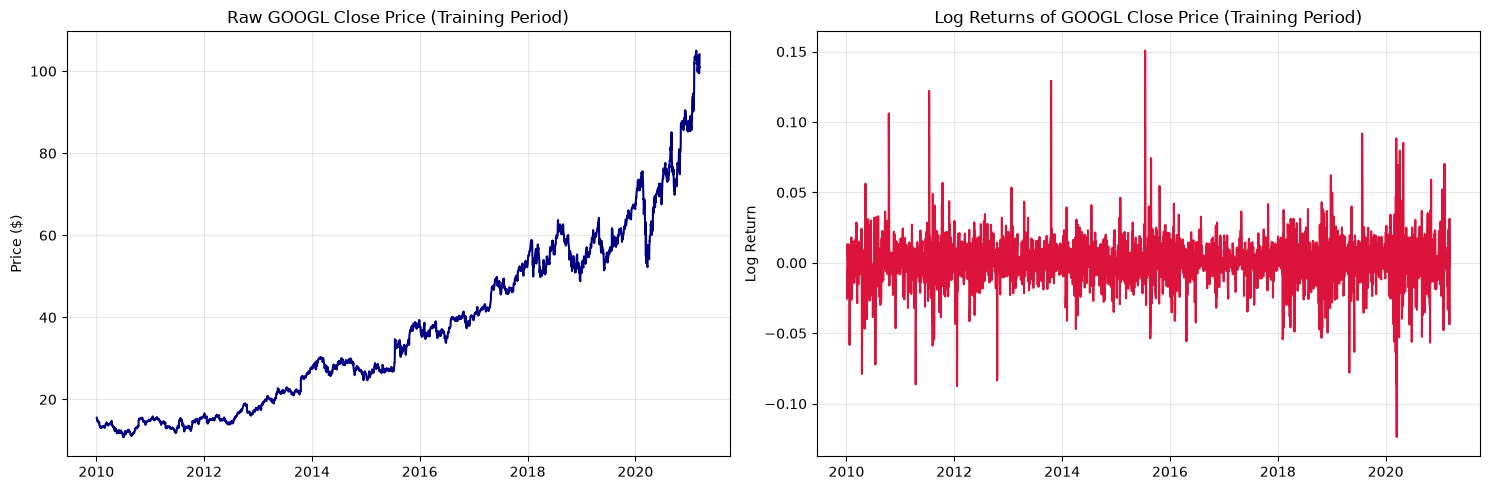

In [10]:
dates_train = df.index[:n_train]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(dates_train, prices_train, color="navy", label="GOOGL Close")
axes[0].set_title("Raw GOOGL Close Price (Training Period)")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

log_returns = np.diff(np.log(prices_train))
axes[1].plot(dates_train[1:], log_returns, color="crimson", label="Log Returns")
axes[1].set_title("Log Returns of GOOGL Close Price (Training Period)")
axes[1].set_ylabel("Log Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
check_stationarity(prices_train, name="Raw GOOGL Prices")
check_stationarity(log_returns, name="Daily Log Returns")


--- Stationarity Analysis for: Raw GOOGL Prices ---
ADF Statistic: 2.0893
ADF p-value:   9.9878e-01
  => ADF Result: Non-Stationary / Unit Root (Fail to reject H0)
KPSS Statistic: 8.2941
KPSS p-value:   1.0000e-02
  => KPSS Result: Non-Stationary (Reject H0 at 5% significance)

--- Stationarity Analysis for: Daily Log Returns ---
ADF Statistic: -17.8677
ADF p-value:   3.0361e-30
  => ADF Result: Stationary (Reject H0 at 5% significance)
KPSS Statistic: 0.1070
KPSS p-value:   1.0000e-01
  => KPSS Result: Stationary (Fail to reject H0)


# SBTS synthetic samples generation

- Raw prices: $S_0, S_1,\ldots, S_N$ (observed at $0 = t_0 < t_1 <\ldots < t_N$)

- Log-returns: $R_{t_i} = \log \frac{R_{t_{i}} } {R_{t_{i-1}}} $

- Observed series: $X_{t_i} = \log \frac{S_{t_i}} {S_{t_0}} = \sum_{j=1}^i R_{t_j} $, with $X_{t_0} = 0$.

- Increments: $X_{t_{i+1}} - X_{t_i} = R_{t_{i+1}} $

- Under $\mathbb{W}^\sigma$, the theoretical variance of the increment is:

$ \text{ Var }   (  X_{t_{i+1}} - X_{t_i} $ ) = $ \sigma^2 (t_{i+1} - t_i) =\sigma^2 \Delta t $ (when it is an uniform grid  $  t_{i+1} - t_i = \Delta t $ )

- The empirical variance of the increment is:

$ \text{ Var }   (  X_{t_{i+1}} - X_{t_i}  )= \text{ Var }  (R_{t_{i+1}}) = [\sigma(R)]^2  $ (where $\sigma(R)$ is the empirical std of the log return series) 

- Equating the two variance yieds: $\hat{\sigma} = \frac{\sigma(R)}{\sqrt{\Delta t}}$ with $\hat{\sigma}$ is the estimator for $\sigma$.

- Define the rescaled observed series $\tilde{X_{t_i} } = X_{t_i} /\hat{\sigma}$ and rescaled log-returns $\tilde{R}_{t_i} = R_{t_i} /\hat{\sigma}$

- We have the increments of the rescaled process are:

$ \text{ Var }   (  \tilde{X}_{t_{i+1}} - \tilde{ X}_{t_i} )= \text{ Var }  (\tilde{ R}_{t_{i+1}} ) =  \text{ Var } (R_{t_{i+1}} \cdot \frac{\sqrt{\Delta t}}{\sigma(R)}  )   = \Delta t      $

This is exactly the increment law of the standard 
$\mathbb{W}$ reference (with $σ=1$). So dividing by the true $σ$ turns 
$X$'s reference from $\mathbb{W}^\sigma$ into exactly $\mathbb{W}$.

In [ ]:
R = np.log(X_train[:, 1:] / X_train[:, :-1])       

sigma_R = np.std(R)

deltat = 1.0 / N

R_tilde = R * np.sqrt(deltat) / sigma_R 

In [13]:
X_ref = np.concatenate([np.zeros((M, 1)), R_tilde], axis=1)

print("X_ref shape:", X_ref.shape)

# Convert VAL windows using TRAINING sigma_R (no leakage)
R_val = np.log(X_val[:, 1:] / X_val[:, :-1])
R_val_tilde = R_val * np.sqrt(deltat) / sigma_R
X_val_ref = np.concatenate([np.zeros((X_val.shape[0], 1)), R_val_tilde], axis=1)

X_ref shape: (2756, 61)


## CV

In [14]:
from models.cv_sbts import cv_mse_plain, cv_mse_markov

X_train_ref = X_ref

N_pi = 100
deltati = 1.0 / 60
L = 30   # realizations per query path
Q = 80   # number of held-out validation query paths

rng = np.random.default_rng(42)
idx_q = rng.choice(X_val_ref.shape[0], size=Q, replace=False)  

# Plain version: grid over h 
h_grid = [0.05, 0.1, 0.15, 0.18, 0.2, 0.22, 0.25, 0.3, 0.4, 0.5]
results_plain = {}
for h in h_grid:
    np.random.seed(1)  
    results_plain[h] = cv_mse_plain(X_train_ref, X_val_ref, h, N, N_pi, deltati, L, idx_q)
h_star = min(results_plain, key=results_plain.get)

# Markovian version: grid over K using optimal h_star 
K_grid = [1, 2, 3, 4, 5, 8]
results_mark = {}
for K in K_grid:
    np.random.seed(1)
    results_mark[K] = cv_mse_markov(X_train_ref, X_val_ref, h_star, K, N, N_pi, deltati, L, idx_q)

best_K = min(results_mark, key=results_mark.get)

print(f"Best h: {h_star:.3f}, Best K: {best_K}")

Best h: 0.250, Best K: 1


In [15]:
# Generate synthetic paths — PLAIN version - Optim h
h = h_star         
N_pi = 100         # Euler substeps per interval
M_simu =  X_train.shape[0]  # match training set size 
deltati = deltat

print(f"\nGenerating {M_simu} plain SBTS paths (h={h}, N_pi={N_pi})...")
t0 = time.perf_counter()
data_sb_plain = simusbts(N, M, X_ref, N_pi, h, deltati, M_simu)
print(f"Done in {time.perf_counter()-t0:.1f}s. Shape: {data_sb_plain.shape}")

# Generate synthetic paths — MARKOVIAN version - Optim K
K = best_K          

print(f"\nGenerating {M_simu} Markovian SBTS paths (h={h}, K={K}, N_pi={N_pi})...")
t0 = time.perf_counter()
data_sb_mark = simusbts_mark(N, M, K, X_ref, N_pi, h, deltati, M_simu)
print(f"Done in {time.perf_counter()-t0:.1f}s. Shape: {data_sb_mark.shape}")


Generating 2756 plain SBTS paths (h=0.25, N_pi=100)...
Start time: 15:34:12
Expected finish time: 15:49:27
Finish time: 15:42:38
Time with numba to generate 2756 samples with N_pi=100: 505 seconds.
Done in 505.3s. Shape: (2756, 60)

Generating 2756 Markovian SBTS paths (h=0.25, K=1, N_pi=100)...
Start time: 15:42:38
Expected finish time: 15:47:29
Finish time: 15:49:49
Time with numba to generate 2756 samples with N_pi=100: 430 seconds.
Done in 430.8s. Shape: (2756, 60)


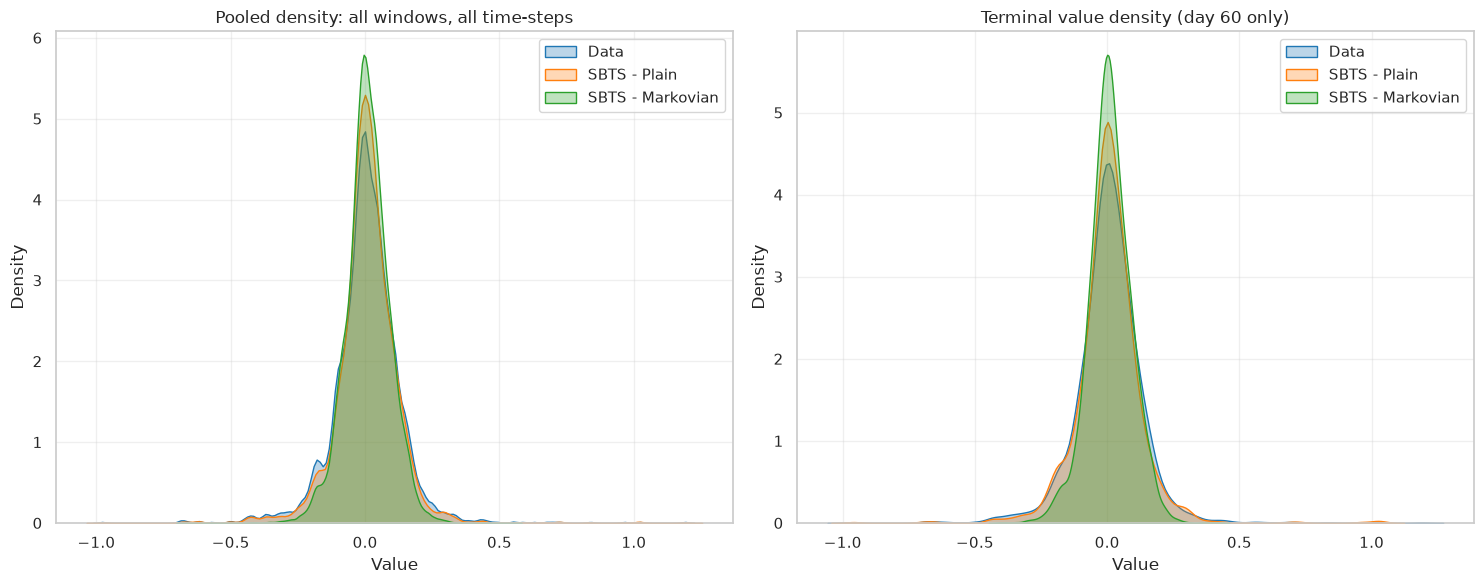

In [16]:
sns.set_theme(style="whitegrid", rc={"grid.alpha": 0.3})

real_flat = R_tilde.flatten()
plain_flat = data_sb_plain.flatten()
mark_flat = data_sb_mark.flatten()

real_t = R_tilde[:, -1]
plain_t = data_sb_plain[:, -1]
mark_t = data_sb_mark[:, -1]

plot_config = {
    "fill": True,
    "common_norm": False,
    "alpha": 0.3,
    "legend": True,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.kdeplot(real_flat, color="#1f77b4", label="Data", ax=axes[0], **plot_config)
sns.kdeplot(plain_flat, color="#ff7f0e", label="SBTS - Plain", ax=axes[0], **plot_config)
sns.kdeplot(mark_flat, color="#2ca02c", label="SBTS - Markovian", ax=axes[0], **plot_config)
axes[0].set_title("Pooled density: all windows, all time-steps")
axes[0].set_xlabel("Value")

sns.kdeplot(real_t, color="#1f77b4", label="Data", ax=axes[1], **plot_config)
sns.kdeplot(plain_t, color="#ff7f0e", label="SBTS - Plain", ax=axes[1], **plot_config)
sns.kdeplot(mark_t, color="#2ca02c", label="SBTS - Markovian", ax=axes[1], **plot_config)
axes[1].set_title("Terminal value density (day 60 only)")
axes[1].set_xlabel("Value")

for ax in axes:
    ax.legend(title="", fontsize=11, title_fontsize=12)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

Start time: 15:49:50
Expected finish time: 15:49:52
Finish time: 15:49:52
Time with numba to generate 10 samples with N_pi=100: 1 seconds.
Start time: 15:49:52
Expected finish time: 15:49:53
Finish time: 15:49:53
Time with numba to generate 10 samples with N_pi=100: 1 seconds.


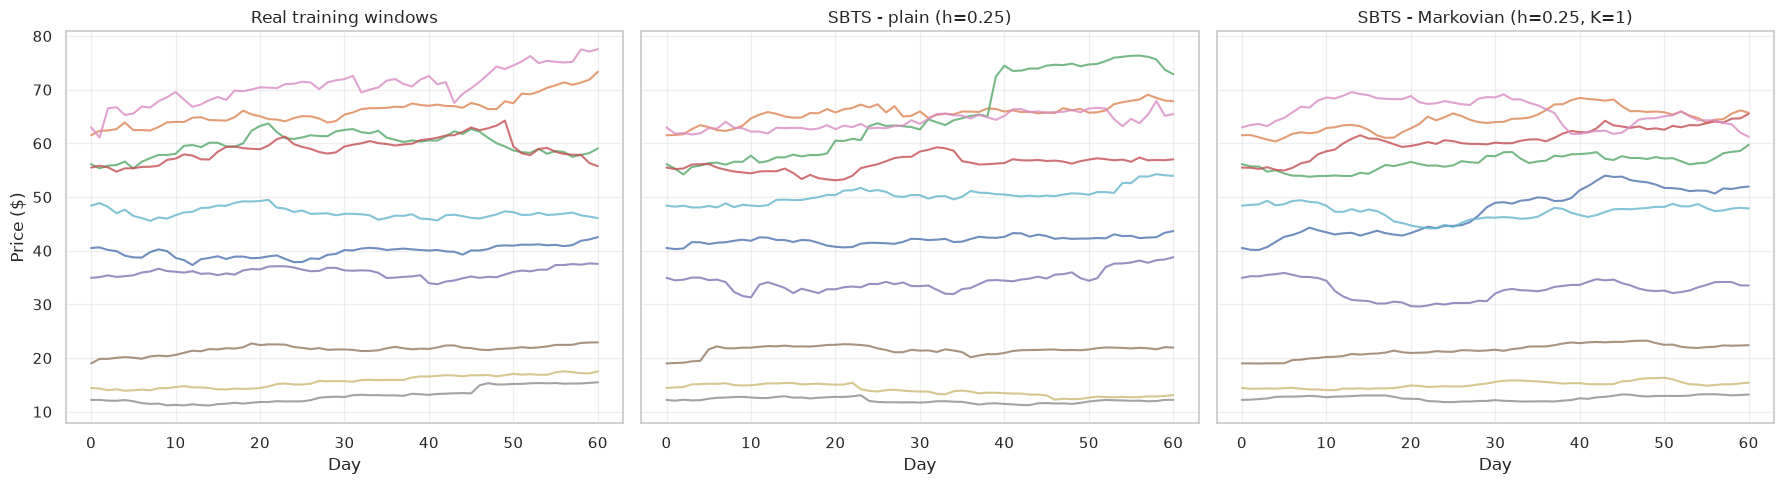

In [17]:
h_plain = h_star
h_mark, K_mark = h_star, best_K
N_pi = 100
deltati = deltat
n_sample = 10

synth_plain = simusbts(N, M, X_ref, N_pi, h_plain, deltati, n_sample)
synth_mark  = simusbts_mark(N, M, K_mark, X_ref, N_pi, h_mark, deltati, n_sample)

def unrescale(synth_rtilde):
    return synth_rtilde * sigma_R / np.sqrt(deltat)

R_synth_plain = unrescale(synth_plain)
R_synth_mark  = unrescale(synth_mark)

rng = np.random.default_rng(7)
start_idx = rng.choice(M, size=n_sample, replace=False)
S0 = X_train[start_idx, 0]

def reconstruct_price(R_synth, S0):
    cum_R = np.cumsum(R_synth, axis=1)
    S = S0[:, None] * np.exp(cum_R)
    return np.concatenate([S0[:, None], S], axis=1)

S_synth_plain = reconstruct_price(R_synth_plain, S0)
S_synth_mark  = reconstruct_price(R_synth_mark, S0)
S_real = X_train[start_idx]


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
days = np.arange(N + 1)

for i in range(n_sample):
    axes[0].plot(days, S_real[i], alpha=0.8)
    axes[1].plot(days, S_synth_plain[i], alpha=0.8)
    axes[2].plot(days, S_synth_mark[i], alpha=0.8)

axes[0].set_title("Real training windows")
axes[1].set_title(f"SBTS - plain (h={h_plain})")
axes[2].set_title(f"SBTS - Markovian (h={h_mark}, K={K_mark})")
for ax in axes:
    ax.set_xlabel("Day")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Price ($)")

plt.tight_layout()
plt.savefig("sbts_sample_paths.png", dpi=110)
plt.show()

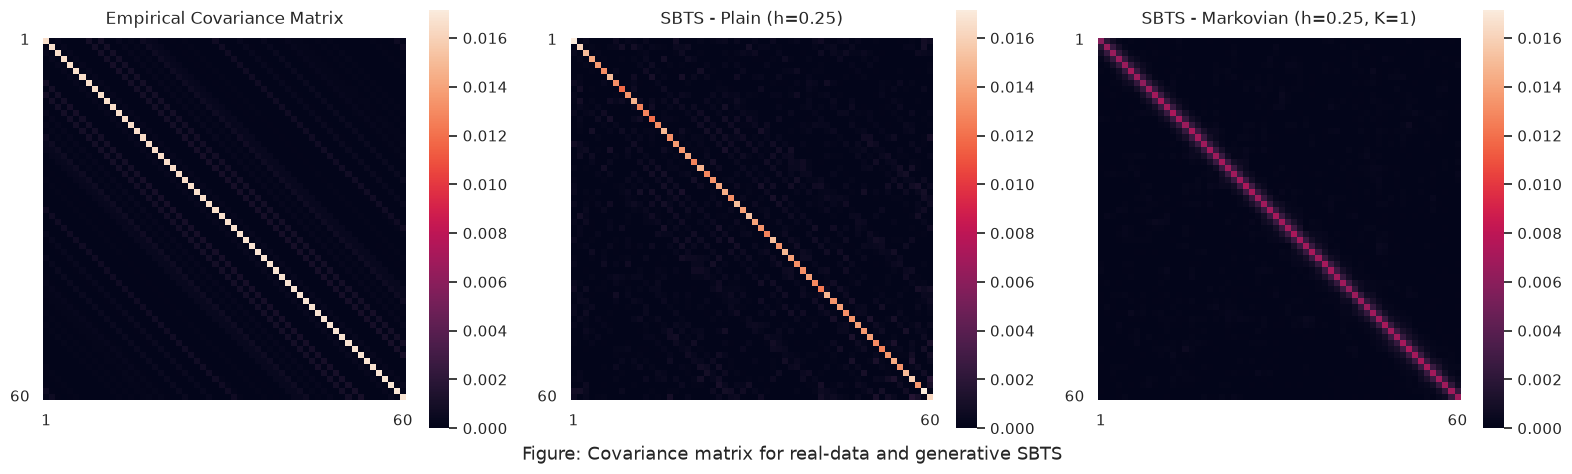

In [18]:
cov_real  = np.cov(R_tilde, rowvar=False)
cov_plain = np.cov(data_sb_plain, rowvar=False)
cov_mark  = np.cov(data_sb_mark, rowvar=False)

vmin = 0.0
vmax = max(cov_real.max(), cov_plain.max(), cov_mark.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

matrices = [cov_real, cov_plain, cov_mark]
titles = [
    "Empirical Covariance Matrix",
    f"SBTS - Plain (h={h_plain})",
    f"SBTS - Markovian (h={h_mark}, K={K_mark})"
]

for ax, matrix, title in zip(axes, matrices, titles):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="rocket",      
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        square=True
    )
    ax.set_title(title, fontsize=12, pad=10)
    
    ax.set_xticks([0.5, 59.5])
    ax.set_xticklabels(["1", "60"], rotation=0)
    ax.set_yticks([0.5, 59.5])
    ax.set_yticklabels(["1", "60"], rotation=0)

plt.suptitle("Figure: Covariance matrix for real-data and generative SBTS", y=0.02, fontsize=13)
plt.tight_layout()
plt.savefig("sbts_covariance_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

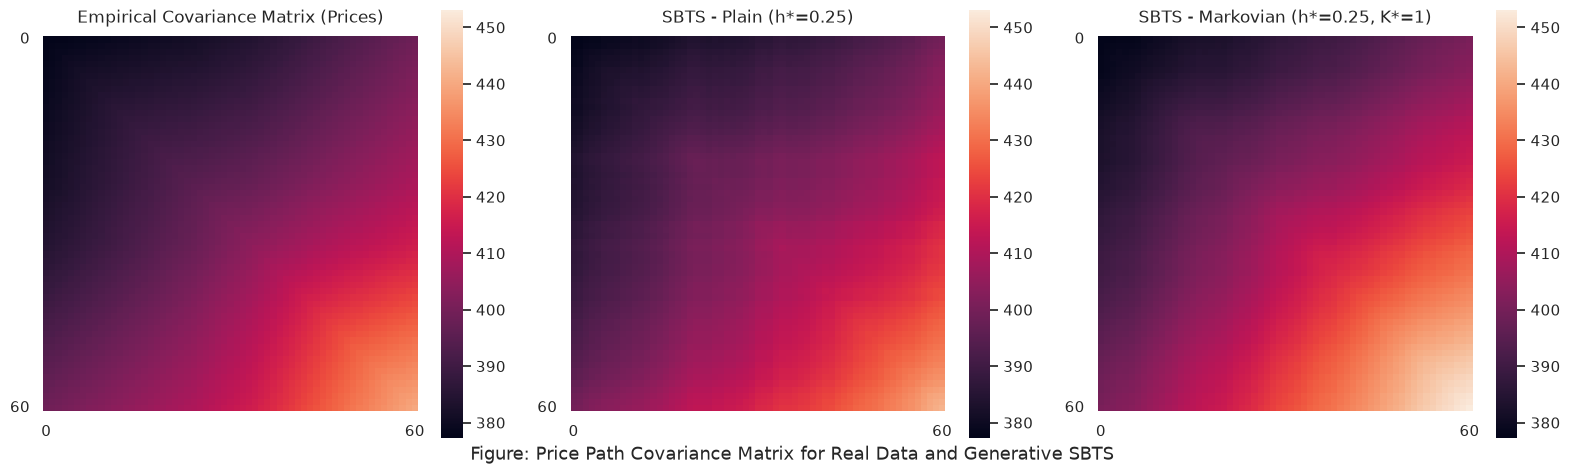

In [19]:
R_synth_plain = data_sb_plain * sigma_R / np.sqrt(deltati)
R_synth_mark  = data_sb_mark  * sigma_R / np.sqrt(deltati)

M_simu = R_synth_plain.shape[0]

rng = np.random.default_rng(7)
start_idx = rng.choice(X_train.shape[0], size=M_simu, replace=False)
S0 = X_train[start_idx, 0]  

def reconstruct_price(R_synth, S0):
    cum_R = np.cumsum(R_synth, axis=1)
    S = S0[:, None] * np.exp(cum_R)
    return np.concatenate([S0[:, None], S], axis=1)

S_real        = X_train[start_idx]                   
S_synth_plain = reconstruct_price(R_synth_plain, S0)  
S_synth_mark  = reconstruct_price(R_synth_mark, S0)   

cov_real  = np.cov(S_real, rowvar=False)
cov_plain = np.cov(S_synth_plain, rowvar=False)
cov_mark  = np.cov(S_synth_mark, rowvar=False)

vmin = min(cov_real.min(), cov_plain.min(), cov_mark.min())
vmax = max(cov_real.max(), cov_plain.max(), cov_mark.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

matrices = [cov_real, cov_plain, cov_mark]
titles = [
    "Empirical Covariance Matrix (Prices)",
    f"SBTS - Plain (h*={h_star:.2f})",
    f"SBTS - Markovian (h*={h_star:.2f}, K*={best_K})"
]

for ax, matrix, title in zip(axes, matrices, titles):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="rocket",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        square=True
    )
    ax.set_title(title, fontsize=12, pad=10)
 
    ax.set_xticks([0.5, 60.5])
    ax.set_xticklabels(["0", "60"], rotation=0)
    ax.set_yticks([0.5, 60.5])
    ax.set_yticklabels(["0", "60"], rotation=0)

plt.suptitle("Figure: Price Path Covariance Matrix for Real Data and Generative SBTS", y=0.02, fontsize=13)
plt.tight_layout()
plt.savefig("sbts_price_covariance_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# Load Data

In [20]:
N = 60

df = yf.download("GOOGL", start="2010-01-01", end="2026-01-01", progress=False)
prices = df["Close"].values.flatten()

train_frac, val_frac = 0.70, 0.15
n_total = len(prices)
n_train = int(n_total * train_frac)
n_val   = int(n_total * val_frac)

prices_train = prices[:n_train]
prices_val   = prices[n_train : n_train + n_val]
prices_test  = prices[n_train + n_val :]

def make_windows(prices, N):
    return np.array([prices[i:i+N+1] for i in range(len(prices) - N)])

X = make_windows(prices_train, N)
X_val = make_windows(prices_val, N)
X_test = make_windows(prices_test, N)

numberOfTimeSteps = X.shape[1] - 1

# Raw (un-normalized) version
dic_data_raw = {
    "train": X,
    "val": X_val,
    "test": X_test
}

# Normalized version: each window divided by its own starting price
dic_data = {
    key: prices / prices[:, [0]]
    for key, prices in dic_data_raw.items()
}

In [21]:
dic_data["train"].shape, dic_data["val"].shape, dic_data["test"].shape

((2756, 61), (543, 61), (545, 61))

In [22]:
print("=== Price range check across train/val/test ===\n")
ranges = {}
for key in ["train", "val", "test"]:
    prices = dic_data_raw[key]
    lo, hi = prices.min(), prices.max()
    ranges[key] = (lo, hi)
    print(f"{key:6s}  min={lo:8.2f}   max={hi:8.2f}   mean={prices.mean():8.2f}")

print("\n=== Overlap check ===")
train_lo, train_hi = ranges["train"]
for key in ["val", "test"]:
    lo, hi = ranges[key]
    overlap = not (hi < train_lo or lo > train_hi)
    print(f"{key} overlaps with train's range [{train_lo:.2f}, {train_hi:.2f}]? -> {overlap}")
    if not overlap:
        gap = lo - train_hi if lo > train_hi else train_lo - hi
        print(f"   -> NO OVERLAP. Gap of {gap:.2f} between train's range and {key}'s range.")

=== Price range check across train/val/test ===

train   min=   10.82   max=  105.00   mean=   36.66
val     min=   82.70   max=  148.52   mean=  117.70
test    min=  121.10   max=  322.81   mean=  172.82

=== Overlap check ===
val overlaps with train's range [10.82, 105.00]? -> True
test overlaps with train's range [10.82, 105.00]? -> False
   -> NO OVERLAP. Gap of 16.10 between train's range and test's range.


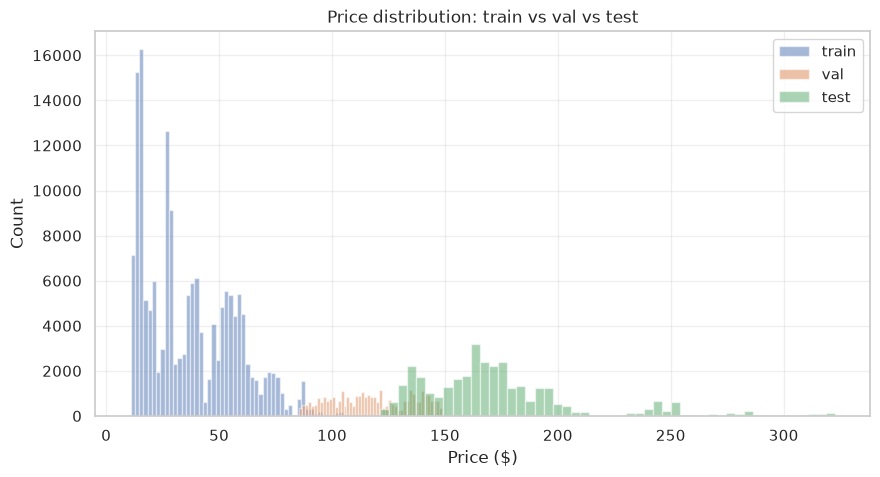

In [23]:
plt.figure(figsize=(10, 5))
for key in ["train", "val", "test"]:
    plt.hist(dic_data_raw[key].flatten(), bins=50, alpha=0.5, label=key)
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.legend()
plt.title("Price distribution: train vs val vs test")
plt.show()

In [24]:
print("=== Price range check across train/val/test ===\n")
ranges = {}
for key in ["train", "val", "test"]:
    prices = dic_data[key]
    lo, hi = prices.min(), prices.max()
    ranges[key] = (lo, hi)
    print(f"{key:6s}  min={lo:8.2f}   max={hi:8.2f}   mean={prices.mean():8.2f}")

print("\n=== Overlap check ===")
train_lo, train_hi = ranges["train"]
for key in ["val", "test"]:
    lo, hi = ranges[key]
    overlap = not (hi < train_lo or lo > train_hi)
    print(f"{key} overlaps with train's range [{train_lo:.2f}, {train_hi:.2f}]? -> {overlap}")
    if not overlap:
        gap = lo - train_hi if lo > train_hi else train_lo - hi
        print(f"   -> NO OVERLAP. Gap of {gap:.2f} between train's range and {key}'s range.")

=== Price range check across train/val/test ===

train   min=    0.69   max=    1.39   mean=    1.02
val     min=    0.68   max=    1.40   mean=    1.01
test    min=    0.70   max=    1.53   mean=    1.05

=== Overlap check ===
val overlaps with train's range [0.69, 1.39]? -> True
test overlaps with train's range [0.69, 1.39]? -> True


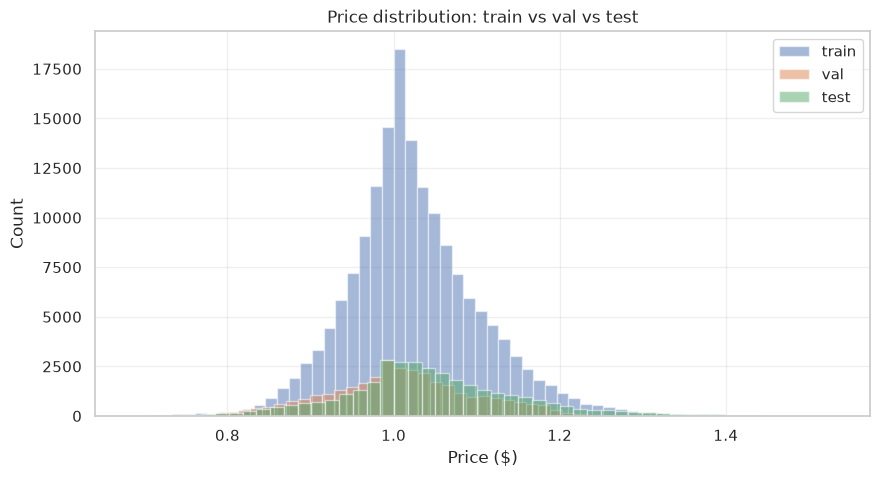

In [25]:
plt.figure(figsize=(10, 5))
for key in ["train", "val", "test"]:
    plt.hist(dic_data[key].flatten(), bins=50, alpha=0.5, label=key)
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.legend()
plt.title("Price distribution: train vs val vs test")
plt.show()

# Deep Hedging using real data

## 1. Train model

In [26]:
deepHedging = DeepHedging(numberOfTimeSteps, dic_data["train"], dic_data["val"], model_name="googl_data")
deepHedging.train_delta_strategy(1000, 128)


epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0082
loss_train = 0.005854903677483573 - loss_val = 0.007034633227576258

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0043
loss_train = 0.00283113399197715 - loss_val = 0.0035073809035906112

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0020
loss_train = 0.001324043388513646 - loss_val = 0.001641697206988961

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0011
loss_train = 0.0008687895658789187 - loss_val = 0.0011950569030428813

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 8.2302e-04
loss_train = 0.0007924422229950266 - loss_val = 0.001311062771318461

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 7.7377e-04
loss_train = 0.0007522054240730456 - loss_val = 0.0014101514371015142

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 7.4552e-04
loss_train = 0.0007339987574648364 - loss_val = 0.001458911619071364

epoch 8/1000
21/21 ━━━

## 2. Results

In [27]:
print(f"price = {np.round(deepHedging.price.numpy(), 4)}")

price = 0.0413


In [28]:
df_stats_deephedging = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedging.columns:
    time = tf.tile(deepHedging.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedging.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedging.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedging.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedging.loc["mean", key] = np.mean(Pnl - payoff)   
    df_stats_deephedging.loc["std", key]  = np.std(Pnl - payoff)    

df_stats_deephedging

,train,val,test
mean,-0.002271,-0.016039,-0.014327
std,0.014906,0.014768,0.016627


# Deep Hedging using SBTS data

## 1. Train model

In [29]:
# data_sb_plain: raw SBTS output rescaled log-returns
print(data_sb_plain.shape) 

# Un-rescale back to real log-return scale
R_synth_plain = data_sb_plain * sigma_R / np.sqrt(deltat)

# Reconstruct actual price paths
rng = np.random.default_rng(123)
S0 = dic_data["train"][rng.integers(0, dic_data["train"].shape[0], size=data_sb_plain.shape[0]), 0]

cum_R = np.cumsum(R_synth_plain, axis=1)
S = S0[:, None] * np.exp(cum_R)
X_sb_plain = np.concatenate([S0[:, None], S], axis=1)   

print(X_sb_plain.shape)   

(2756, 60)
(2756, 61)


In [30]:
deepHedgingSimu = DeepHedging(numberOfTimeSteps, X_sb_plain, dic_data["val"], model_name="googl_sbts_plain")
deepHedgingSimu.train_delta_strategy(1000, 128)


epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0074
loss_train = 0.00467486534395937 - loss_val = 0.005586170495934155

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0030
loss_train = 0.001727884119485465 - loss_val = 0.002328137153131221

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0012
loss_train = 0.0008405264027692525 - loss_val = 0.0013791711599056302

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 8.0441e-04
loss_train = 0.0007938110237797813 - loss_val = 0.0014708114783953572

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 7.8456e-04
loss_train = 0.00076994932133488 - loss_val = 0.0015416570148494202

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 7.6569e-04
loss_train = 0.0007613430580226614 - loss_val = 0.0015923304009985786

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 7.6065e-04
loss_train = 0.0007565312504091198 - loss_val = 0.001613790033608821

epoch 8/1000
21/21

In [31]:
print(f"price = {np.round(deepHedgingSimu.price.numpy(), 8)}")

price = 0.04226749


In [32]:
df_stats_deephedgingSimu = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedgingSimu.columns:
    time = tf.tile(deepHedgingSimu.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedgingSimu.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedgingSimu.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedgingSimu.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedgingSimu.loc["mean", key] = np.mean(Pnl - payoff)
    df_stats_deephedgingSimu.loc["std", key]  = np.std(Pnl - payoff)

df_stats_deephedgingSimu

,train,val,test
mean,-0.001897,-0.015814,-0.012974
std,0.014832,0.014964,0.014302


# Markov SBTS

In [33]:
# data_sb_mark: raw SBTS output rescaled log-returns
print(data_sb_mark.shape) 

# Un-rescale back to real log-return scale
R_synth_mark = data_sb_mark * sigma_R / np.sqrt(deltat)

# Reconstruct actual price paths
rng = np.random.default_rng(123)
S0 = dic_data["train"][rng.integers(0, dic_data["train"].shape[0], size=data_sb_mark.shape[0]), 0]

cum_R = np.cumsum(R_synth_mark, axis=1)
S = S0[:, None] * np.exp(cum_R)
X_sb_mark = np.concatenate([S0[:, None], S], axis=1)   

print(X_sb_mark.shape)   

(2756, 60)
(2756, 61)


In [34]:
deepHedgingSimuMark = DeepHedging(numberOfTimeSteps, X_sb_mark, dic_data["val"], model_name="googl_sbts_mark")
deepHedgingSimuMark.train_delta_strategy(1000, 128)


epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0110
loss_train = 0.007471690123619477 - loss_val = 0.00529458132267977

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0051
loss_train = 0.002980651815909327 - loss_val = 0.002242847302053308

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0020
loss_train = 0.0012265983003121573 - loss_val = 0.0012504047172397417

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0011
loss_train = 0.00099322208624821 - loss_val = 0.001323760113550972

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 9.8761e-04
loss_train = 0.000966447102807286 - loss_val = 0.0014319145743293892

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 9.5925e-04
loss_train = 0.0009441600343058913 - loss_val = 0.0014758930837891755

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 9.4705e-04
loss_train = 0.0009331366360972147 - loss_val = 0.0015289293468891626

epoch 8/1000
21/21 ━━━━

In [35]:
print(f"price = {np.round(deepHedgingSimuMark.price.numpy(), 8)}")

price = 0.03269933


In [36]:
df_stats_deephedgingSimuMark = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedgingSimuMark.columns:
    time = tf.tile(deepHedgingSimuMark.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedgingSimuMark.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedgingSimuMark.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedgingSimuMark.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedgingSimuMark.loc["mean", key] = np.mean(Pnl - payoff)
    df_stats_deephedgingSimuMark.loc["std", key]  = np.std(Pnl - payoff)

df_stats_deephedgingSimuMark

,train,val,test
mean,-0.015414,-0.030968,-0.024545
std,0.023089,0.020048,0.021553


# PnL distribution Data versus SBTS

In [37]:
dic_deephedging_pnl = {}

def get_pnl(deepHedging_model, key):
    time = tf.tile(deepHedging_model.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedging_model.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedging_model.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedging_model.payoff(dic_data[key][:,-1], K).numpy()

    return Pnl - payoff

dic_deephedging_pnl_val = {
    "Data": get_pnl(deepHedging, "val"),
    "SBTS": get_pnl(deepHedgingSimu, "val"),
    "SBTS_Markov": get_pnl(deepHedgingSimuMark, "val")
}

dic_deephedging_pnl_test = {
    "Data": get_pnl(deepHedging, "test"),
    "SBTS": get_pnl(deepHedgingSimu, "test"),
    "SBTS_Markov": get_pnl(deepHedgingSimuMark, "test")
}

In [38]:
def plot_pnl_distribution(dic_deephedging_pnl):
    sns.set_style("whitegrid")

    df_plot = pd.DataFrame()
    pnl_all, legend_all = [], []
    for key, pnl in dic_deephedging_pnl.items():
        pnl_all.extend(np.asarray(pnl).tolist())
        legend_all.extend([key] * len(pnl))

    df_plot["PnL"] = pnl_all
    df_plot["Legend"] = legend_all

    ax = sns.displot(data=df_plot, x="PnL", hue="Legend", kind="kde", height=7, fill=True, ec='Navy', lw=2, alpha=0.5)
    plt.xlabel(r"$\mathrm{PnL}$", fontsize=14)
    plt.ylabel(r"$\mathrm{Density}$", fontsize=14)
    ax._legend.get_title().set_text("")
    plt.setp(ax._legend.get_texts(), fontsize=14)
    return ax

## 1. Validation

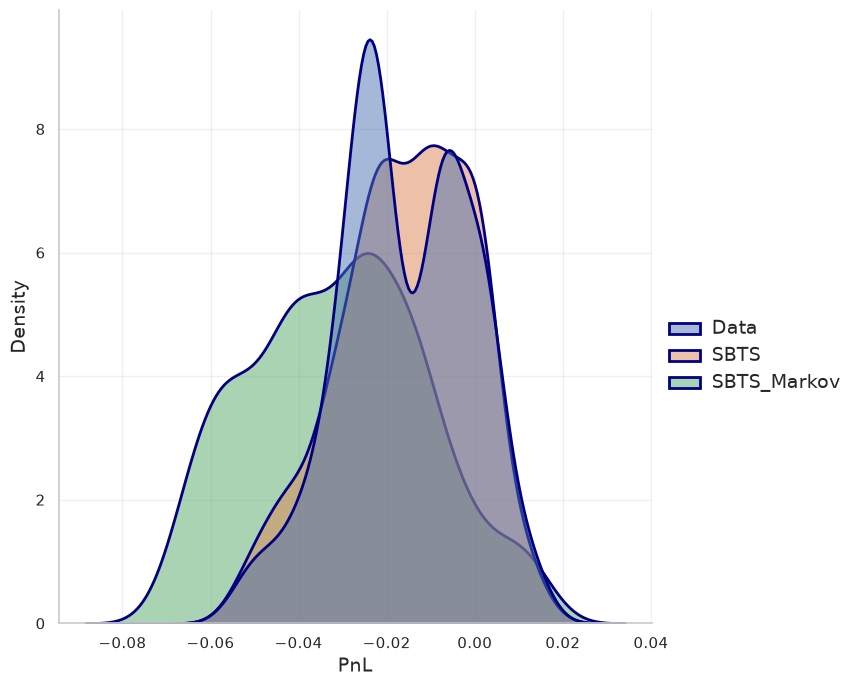

In [39]:
plot_pnl_distribution(dic_deephedging_pnl_val)

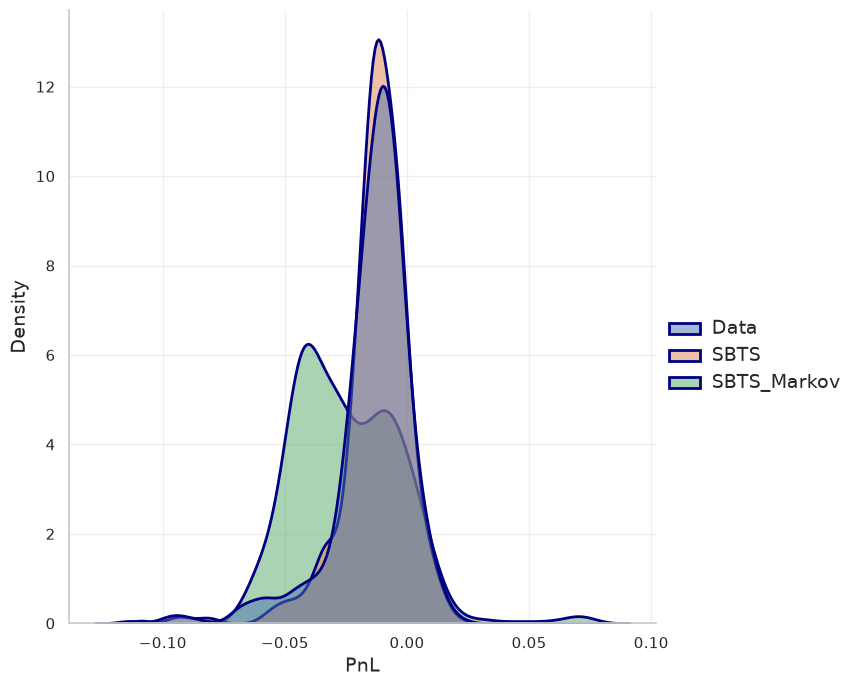

In [40]:
plot_pnl_distribution(dic_deephedging_pnl_test)

In [41]:
def plot_pnl_pair(dic_deephedging_pnl, key_a="Data", key_b="SBTS", title=None):
    sns.set_style("whitegrid")

    df_plot = pd.DataFrame()
    pnl_all, legend_all = [], []
    for key in [key_a, key_b]:
        pnl = np.asarray(dic_deephedging_pnl[key])
        pnl_all.extend(pnl.tolist())
        legend_all.extend([key] * len(pnl))

        print(f"{key:15s}  mean = {pnl.mean(): .5f}   std = {pnl.std():.5f}")

    df_plot["PnL"] = pnl_all
    df_plot["Legend"] = legend_all

    ax = sns.displot(data=df_plot, x="PnL", hue="Legend", kind="kde", height=7, fill=True, ec='Navy', lw=2, alpha=0.5)
    plt.xlabel(r"$\mathrm{PnL}$", fontsize=14)
    plt.ylabel(r"$\mathrm{Density}$", fontsize=14)
    ax._legend.get_title().set_text("")
    plt.setp(ax._legend.get_texts(), fontsize=14)
    if title:
        plt.title(title, fontsize=14)
    return ax

=== Data vs SBTS (plain) ===
Data             mean = -0.01604   std = 0.01477
SBTS             mean = -0.01581   std = 0.01496


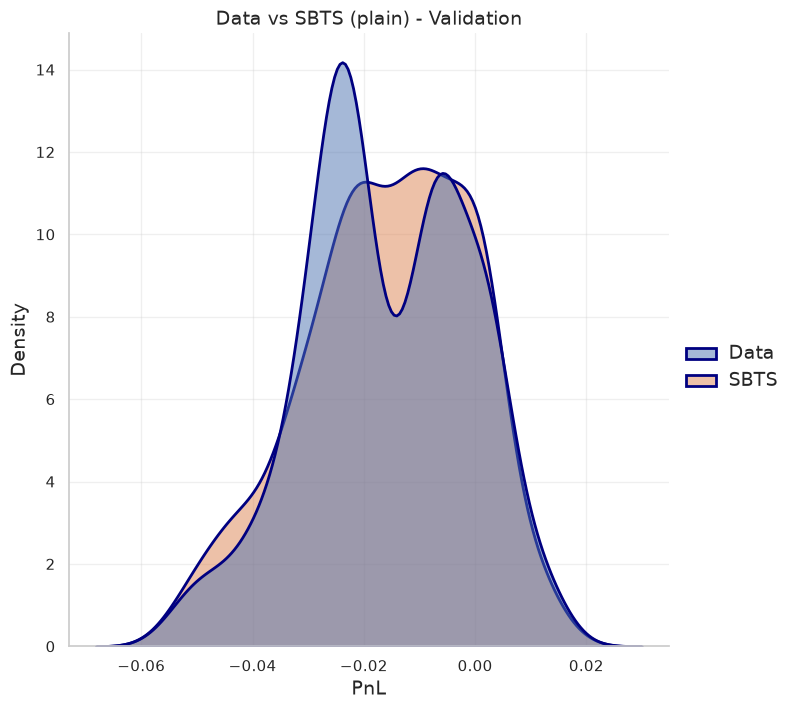


=== Data vs SBTS (Markovian) ===
Data             mean = -0.01604   std = 0.01477
SBTS_Markov      mean = -0.03097   std = 0.02005


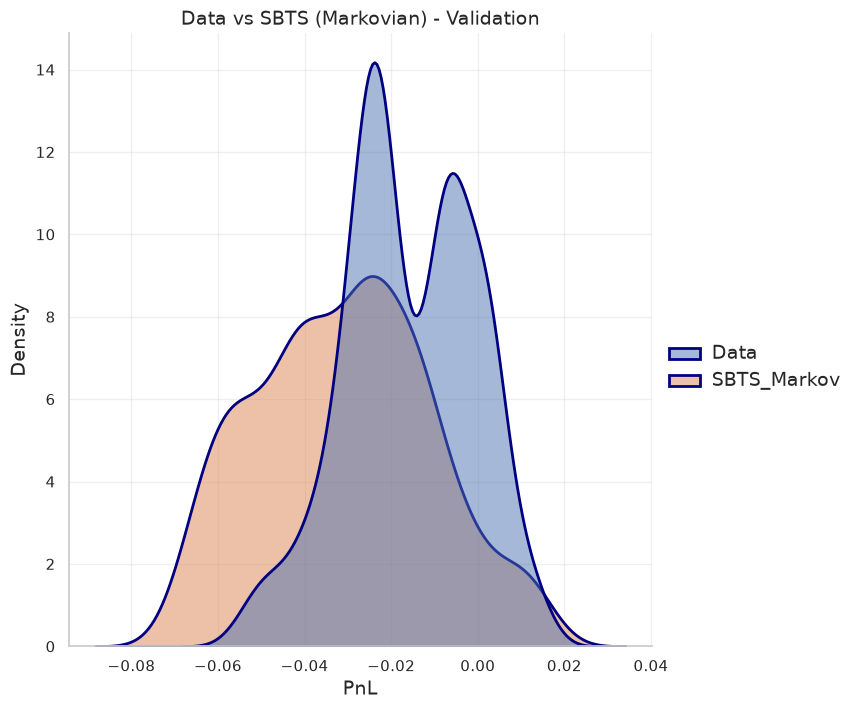

In [42]:
print("=== Data vs SBTS (plain) ===")
plot_pnl_pair(dic_deephedging_pnl_val, "Data", "SBTS", title="Data vs SBTS (plain) - Validation")
plt.show()

print("\n=== Data vs SBTS (Markovian) ===")
plot_pnl_pair(dic_deephedging_pnl_val, "Data", "SBTS_Markov", title="Data vs SBTS (Markovian) - Validation")
plt.show()

Data             mean = -0.01433   std = 0.01663
SBTS             mean = -0.01297   std = 0.01430


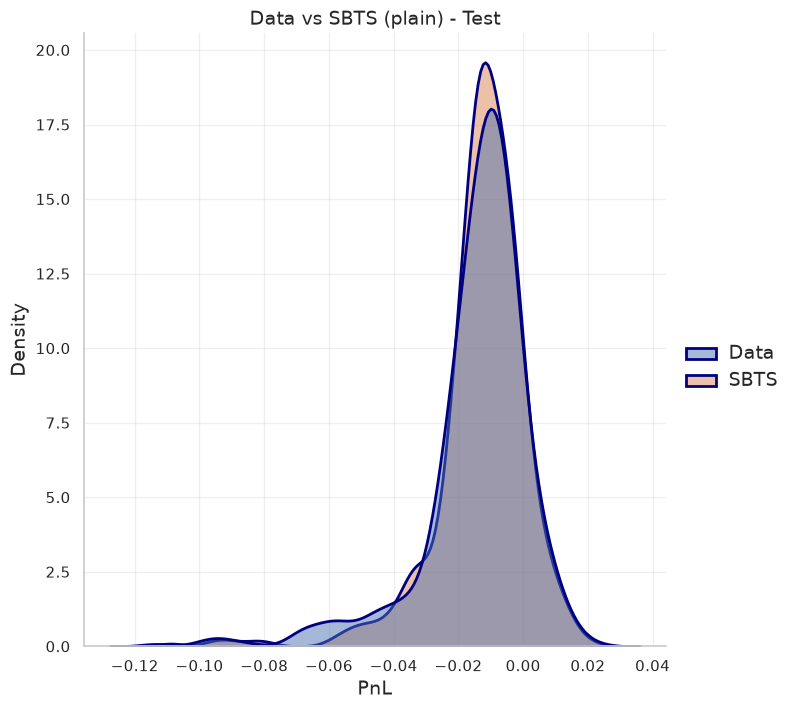

Data             mean = -0.01433   std = 0.01663
SBTS_Markov      mean = -0.02454   std = 0.02155


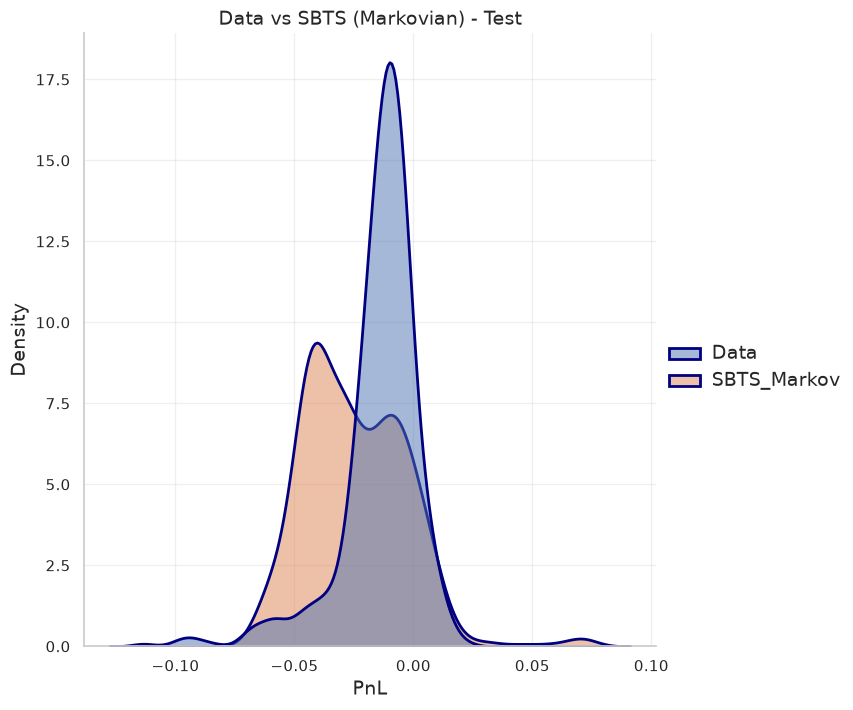

In [43]:
# Data vs SBTS (plain)
plot_pnl_pair(dic_deephedging_pnl_test, "Data", "SBTS", title="Data vs SBTS (plain) - Test")
plt.show()

# Data vs SBTS_Markov
plot_pnl_pair(dic_deephedging_pnl_test, "Data", "SBTS_Markov", title="Data vs SBTS (Markovian) - Test")
plt.show()